In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/delivery_master.csv")
print("Rows, columns:", df.shape)
print("On-time rate:", round(df.on_time.mean() * 100, 1), "%")
print("Avg delivery days:", round(df.delivery_days.mean(), 1))

Rows, columns: (95964, 36)
On-time rate: 92.3 %
Avg delivery days: 12.2


                orders  late_pct  avg_days
customer_state                            
AL                 393      23.2      24.0
MA                 707      18.5      20.9
PI                 470      14.9      18.4
SE                 331      14.2      20.2
CE                1249      13.4      19.9
BA                3219      13.0      18.6
TO                 273      12.5      17.5
RJ               12187      12.3      14.6
ES                1983      11.7      15.3
MS                 700      11.4      15.6


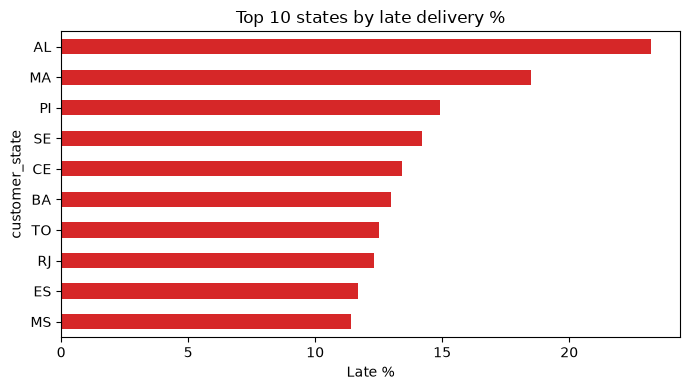

In [4]:
state = (df.groupby("customer_state")
           .agg(orders=("order_id", "count"),
                late_pct=("is_late", "mean"),
                avg_days=("delivery_days", "mean"))
           .query("orders > 200")
           .sort_values("late_pct", ascending=False))
state["late_pct"] = (state.late_pct * 100).round(1)
state["avg_days"] = state.avg_days.round(1)
print(state.head(10))

state.late_pct.head(10).sort_values().plot(
    kind="barh", color="#d62728", figsize=(7, 4),
    title="Top 10 states by late delivery %")
plt.xlabel("Late %")
plt.tight_layout()
plt.savefig("../images/eda_late_by_state.png", dpi=150)
plt.show()


In [5]:
lane = (df.groupby("lane")
          .agg(orders=("order_id", "count"),
               late_pct=("is_late", "mean"),
               transit=("carrier_transit_days", "mean"))
          .query("orders > 150")
          .sort_values("late_pct", ascending=False))
lane["late_pct"] = (lane.late_pct * 100).round(1)
lane["transit"] = lane.transit.round(1)
print(lane.head(10))

         orders  late_pct  transit
lane                              
SP → AL     253      25.7     21.5
SP → MA     483      19.9     18.1
SP → PI     324      17.0     15.6
SP → SE     205      15.1     16.5
SP → MS     476      14.5     12.6
SP → RJ    8042      14.3     12.2
SP → BA    2284      14.1     16.0
SP → ES    1454      13.8     12.1
SP → CE     949      13.6     16.9
PR → RJ     947      12.6     13.1


In [6]:
print(df[["seller_handling_days", "carrier_transit_days"]].describe().round(2))

       seller_handling_days  carrier_transit_days
count              95949.00              95963.00
mean                   2.77                  9.05
std                    3.34                  7.39
min                 -171.22                  0.00
25%                    0.87                  4.09
50%                    1.81                  7.09
75%                    3.56                 11.97
max                   49.59                178.27


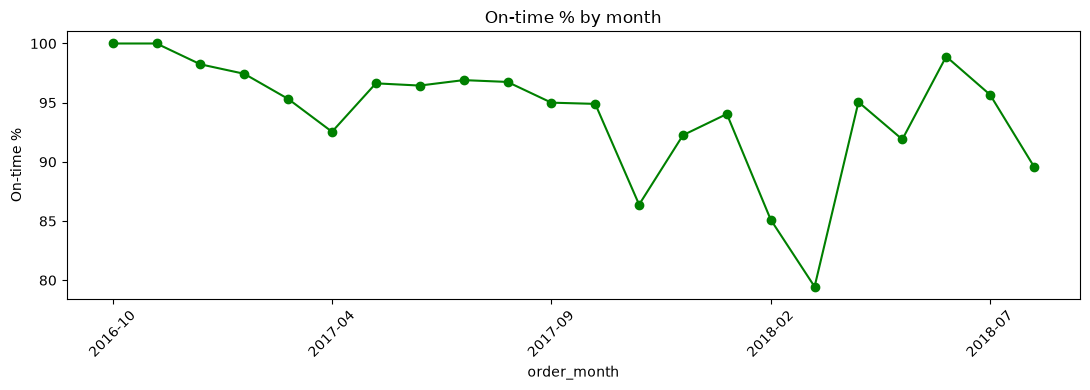

order_month
2018-03    79.5
2018-02    85.1
2017-11    86.4
2018-08    89.6
2018-05    91.9
Name: on_time, dtype: float64


In [7]:
m = df.groupby("order_month").on_time.mean().mul(100)

m.plot(figsize=(11, 4), marker="o", color="green",
       title="On-time % by month")
plt.ylabel("On-time %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/eda_monthly_trend.png", dpi=150)
plt.show()

print(m.sort_values().head(5).round(1))   # 5 worst months

delay_bucket
On time          4.29
1-3 days late    3.77
4-7 days late    2.32
7+ days late     1.70
Name: review_score, dtype: float64


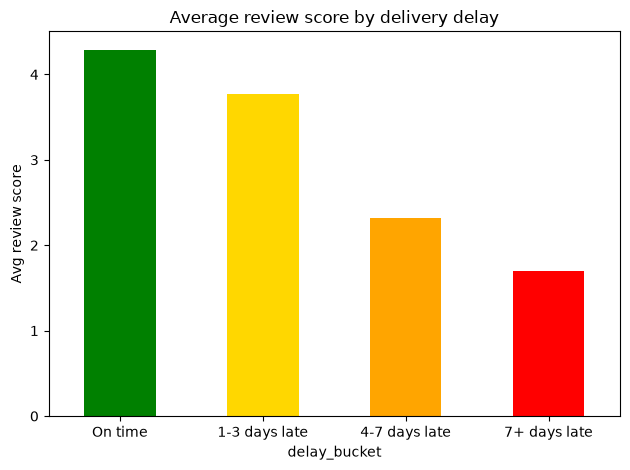

In [8]:
order = ["On time", "1-3 days late", "4-7 days late", "7+ days late"]
r = (df.groupby("delay_bucket").review_score.mean()
       .reindex(order).round(2))
print(r)

r.plot(kind="bar", color=["green", "gold", "orange", "red"],
       title="Average review score by delivery delay")
plt.ylabel("Avg review score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/eda_review_by_delay.png", dpi=150)
plt.show()

In [9]:
print(df.groupby("same_state")[["delivery_days", "is_late"]].mean().round(3))

            delivery_days  is_late
same_state                        
0                  14.733    0.086
1                   7.829    0.059


## Key Findings
- Overall on-time rate is X% with an average delivery time of Y days.
- Highest late rates: AL (X%), MA (X%), SE (X%) vs SP at X%.
- Worst lane: SP → AL with X% late and Y transit days.
- Seller handling averages X days vs Y days of carrier transit.
- Worst months: Nov 2017 (X% on-time), Feb 2018 (X%).
- Late orders (7+ days) score X stars vs Y for on-time orders.
- Cross-state orders are N times more likely to be late than same-state.

In [10]:
import pandas as pd

df = pd.read_csv("../data/processed/delivery_master.csv")
late = df[df.is_late == 1]
print(late.groupby("customer_state").delay_days.mean().round(1).sort_values(ascending=False).head(5))

customer_state
SE    10.1
RJ     9.7
CE     9.2
PE     9.0
RN     8.1
Name: delay_days, dtype: float64
